# Importing Libraries and Datasets






In [ ]:
!pip install torchtuples pycox lifelines streamlit --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torchtuples as tt
from pycox.models import CoxPH
import torch
from torch import nn
from lifelines.utils import concordance_index
import streamlit as st
import joblib

In [ ]:
accounts = pd.read_csv("/content/drive/MyDrive/Churn Data/ravenstack_accounts.csv")
churn = pd.read_csv("/content/drive/MyDrive/Churn Data/ravenstack_churn_events.csv")
usage = pd.read_csv("/content/drive/MyDrive/Churn Data/ravenstack_feature_usage.csv")
subscriptions = pd.read_csv("/content/drive/MyDrive/Churn Data/ravenstack_subscriptions.csv")
tickets = pd.read_csv("/content/drive/MyDrive/Churn Data/ravenstack_support_tickets.csv")

# Viewing Datasets

In [ ]:
accounts.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [ ]:
subscriptions.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


In [ ]:
usage.head()

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


In [ ]:
tickets.head()

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False


In [ ]:
churn.head()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


In [ ]:
print("Accounts:", accounts.shape)
print("Subscriptions:", subscriptions.shape)
print("Feature Usage:", usage.shape)
print("Support Tickets:", tickets.shape)
print("Churn Events:", churn.shape)

Accounts: (500, 10)
Subscriptions: (5000, 14)
Feature Usage: (25000, 8)
Support Tickets: (2000, 9)
Churn Events: (600, 9)


# Data Transformation

In [ ]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   account_id       500 non-null    object
 1   account_name     500 non-null    object
 2   industry         500 non-null    object
 3   country          500 non-null    object
 4   signup_date      500 non-null    object
 5   referral_source  500 non-null    object
 6   plan_tier        500 non-null    object
 7   seats            500 non-null    int64 
 8   is_trial         500 non-null    bool  
 9   churn_flag       500 non-null    bool  
dtypes: bool(2), int64(1), object(7)
memory usage: 32.4+ KB


No Null Values in Accounts Table and signup_date incorrect data type


In [ ]:
subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_id    5000 non-null   object
 1   account_id         5000 non-null   object
 2   start_date         5000 non-null   object
 3   end_date           486 non-null    object
 4   plan_tier          5000 non-null   object
 5   seats              5000 non-null   int64 
 6   mrr_amount         5000 non-null   int64 
 7   arr_amount         5000 non-null   int64 
 8   is_trial           5000 non-null   bool  
 9   upgrade_flag       5000 non-null   bool  
 10  downgrade_flag     5000 non-null   bool  
 11  churn_flag         5000 non-null   bool  
 12  billing_frequency  5000 non-null   object
 13  auto_renew_flag    5000 non-null   bool  
dtypes: bool(5), int64(3), object(6)
memory usage: 376.1+ KB


Wrong data type in start_date and end_date and no null values to be handled

In [ ]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   usage_id             25000 non-null  object
 1   subscription_id      25000 non-null  object
 2   usage_date           25000 non-null  object
 3   feature_name         25000 non-null  object
 4   usage_count          25000 non-null  int64 
 5   usage_duration_secs  25000 non-null  int64 
 6   error_count          25000 non-null  int64 
 7   is_beta_feature      25000 non-null  bool  
dtypes: bool(1), int64(3), object(4)
memory usage: 1.4+ MB


No null values but usage_date has incorrect data type

In [ ]:
tickets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ticket_id                    2000 non-null   object 
 1   account_id                   2000 non-null   object 
 2   submitted_at                 2000 non-null   object 
 3   closed_at                    2000 non-null   object 
 4   resolution_time_hours        2000 non-null   float64
 5   priority                     2000 non-null   object 
 6   first_response_time_minutes  2000 non-null   int64  
 7   satisfaction_score           1175 non-null   float64
 8   escalation_flag              2000 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(5)
memory usage: 127.1+ KB


satisfaction_score has null values and submitted_at and closed_at are of wrong data type


In [ ]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   churn_event_id            600 non-null    object 
 1   account_id                600 non-null    object 
 2   churn_date                600 non-null    object 
 3   reason_code               600 non-null    object 
 4   refund_amount_usd         600 non-null    float64
 5   preceding_upgrade_flag    600 non-null    bool   
 6   preceding_downgrade_flag  600 non-null    bool   
 7   is_reactivation           600 non-null    bool   
 8   feedback_text             452 non-null    object 
dtypes: bool(3), float64(1), object(5)
memory usage: 30.0+ KB


feedback_text has null values and churn_date has incorrect data type


In [ ]:
accounts["signup_date"] = pd.to_datetime(accounts["signup_date"])

subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])

usage["usage_date"] = pd.to_datetime(usage["usage_date"])

tickets["submitted_at"] = pd.to_datetime(tickets["submitted_at"])
tickets["closed_at"] = pd.to_datetime(tickets["closed_at"])

churn["churn_date"] = pd.to_datetime(churn["churn_date"])

# Data Cleaning

**Checking missing value**

In [ ]:
accounts.isnull().sum()

,0
account_id,0
account_name,0
industry,0
country,0
signup_date,0
referral_source,0
plan_tier,0
seats,0
is_trial,0
churn_flag,0


In [ ]:
subscriptions.isnull().sum()

,0
subscription_id,0
account_id,0
start_date,0
end_date,4514
plan_tier,0
seats,0
mrr_amount,0
arr_amount,0
is_trial,0
upgrade_flag,0


In [ ]:
usage.isnull().sum()

,0
usage_id,0
subscription_id,0
usage_date,0
feature_name,0
usage_count,0
usage_duration_secs,0
error_count,0
is_beta_feature,0


In [ ]:
tickets.isnull().sum()

,0
ticket_id,0
account_id,0
submitted_at,0
closed_at,0
resolution_time_hours,0
priority,0
first_response_time_minutes,0
satisfaction_score,825
escalation_flag,0


In [ ]:
churn.isnull().sum()

,0
churn_event_id,0
account_id,0
churn_date,0
reason_code,0
refund_amount_usd,0
preceding_upgrade_flag,0
preceding_downgrade_flag,0
is_reactivation,0
feedback_text,148


**Handling Null Values**

In [ ]:
tickets["satisfaction_score"] = tickets["satisfaction_score"].fillna(tickets["satisfaction_score"].mean())

**Dropping Duplicates**

In [ ]:
accounts.drop_duplicates()
subscriptions.drop_duplicates()
usage.drop_duplicates()
tickets.drop_duplicates()
churn.drop_duplicates()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive
...,...,...,...,...,...,...,...,...,...
595,C-b56a35,A-702032,2024-06-14,competitor,0.00,False,False,False,switched to competitor
596,C-7e7822,A-dbc825,2024-02-03,budget,0.00,False,False,False,NaN
597,C-484fba,A-0a282f,2024-12-31,support,62.66,False,True,False,too expensive
598,C-22f536,A-e5d6ab,2024-05-11,competitor,0.00,True,False,False,NaN


No duplicates found


**Checking Inconsistent Categories**

In [ ]:
accounts["country"].unique()


array(['US', 'IN', 'UK', 'CA', 'DE', 'AU', 'FR'], dtype=object)

In [ ]:
accounts["industry"].unique()

array(['EdTech', 'FinTech', 'DevTools', 'HealthTech', 'Cybersecurity'],
      dtype=object)

**Handling Negative and Invalid Values**

In [ ]:
subscriptions[['mrr_amount','arr_amount']].describe()

,mrr_amount,arr_amount
count,5000.000000,5000.000000
mean,2267.749400,27212.992800
std,3421.375348,41056.504178
min,0.000000,0.000000
25%,285.000000,3420.000000
50%,931.000000,11172.000000
75%,2786.000000,33432.000000
max,33830.000000,405960.000000


In [ ]:
subscriptions = subscriptions[subscriptions['arr_amount']>=0]

In [ ]:
subscriptions = subscriptions[subscriptions['mrr_amount'] >= 0]

No negative value since minimum value is zero for ARR and MRR

# Data Integration


Merging Accounts and Subscriptions table

In [ ]:
data = accounts.merge(subscriptions,on="account_id",how = "left" )
data

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_x,seats_x,is_trial_x,churn_flag_x,...,plan_tier_y,seats_y,mrr_amount,arr_amount,is_trial_y,upgrade_flag,downgrade_flag,churn_flag_y,billing_frequency,auto_renew_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,Basic,11,209,2508,False,False,False,False,monthly,True
1,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,Pro,20,980,11760,False,False,False,False,monthly,True
2,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,Pro,9,441,5292,False,False,False,False,monthly,True
3,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,Enterprise,9,1791,21492,False,False,False,False,annual,False
4,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,Basic,102,1938,23256,False,False,False,False,monthly,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,Basic,12,228,2736,False,False,False,False,annual,True
4996,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,Pro,20,980,11760,False,False,False,False,monthly,False
4997,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,Basic,12,228,2736,False,False,False,False,annual,True
4998,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,Enterprise,12,2388,28656,False,False,False,False,annual,True


Integrating Churn

In [ ]:
data = data.merge(churn[['account_id', 'churn_date']], on='account_id', how='left')
data

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_x,seats_x,is_trial_x,churn_flag_x,...,seats_y,mrr_amount,arr_amount,is_trial_y,upgrade_flag,downgrade_flag,churn_flag_y,billing_frequency,auto_renew_flag,churn_date
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,11,209,2508,False,False,False,False,monthly,True,2024-11-23
1,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,11,209,2508,False,False,False,False,monthly,True,2024-12-05
2,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,20,980,11760,False,False,False,False,monthly,True,2024-11-23
3,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,20,980,11760,False,False,False,False,monthly,True,2024-12-05
4,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,9,441,5292,False,False,False,False,monthly,True,2024-11-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7424,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,12,228,2736,False,False,False,False,annual,True,2024-10-12
7425,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,12,2388,28656,False,False,False,False,annual,True,2024-12-09
7426,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,12,2388,28656,False,False,False,False,annual,True,2024-10-12
7427,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,12,2388,28656,False,True,False,False,monthly,True,2024-12-09


Integrating Aggregated Feature Usage

In [ ]:
agg_usage = usage.groupby('subscription_id').agg({'usage_count':'sum',
                                                  'usage_duration_secs':'sum',
                                                  'error_count':'sum'}).reset_index()


In [ ]:
data = data.merge(agg_usage, on = 'subscription_id', how = 'left')
data

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_x,seats_x,is_trial_x,churn_flag_x,...,is_trial_y,upgrade_flag,downgrade_flag,churn_flag_y,billing_frequency,auto_renew_flag,churn_date,usage_count,usage_duration_secs,error_count
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,False,False,False,False,monthly,True,2024-11-23,42.0,12313.0,0.0
1,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,False,False,False,False,monthly,True,2024-12-05,42.0,12313.0,0.0
2,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,False,False,False,False,monthly,True,2024-11-23,46.0,13363.0,4.0
3,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,False,False,False,False,monthly,True,2024-12-05,46.0,13363.0,4.0
4,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,False,False,False,False,monthly,True,2024-11-23,44.0,9964.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7424,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,False,False,False,False,annual,True,2024-10-12,72.0,19614.0,4.0
7425,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,False,False,False,False,annual,True,2024-12-09,91.0,24232.0,5.0
7426,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,False,False,False,False,annual,True,2024-10-12,91.0,24232.0,5.0
7427,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,False,True,False,False,monthly,True,2024-12-09,80.0,25258.0,3.0


Integrating Aggregated Support Tickets


In [ ]:
agg_tickets = tickets.groupby('account_id').agg({'ticket_id':'count',
                                                 'resolution_time_hours':'mean',
                                                 'satisfaction_score':'mean'}).reset_index()

In [ ]:
data = data.merge(agg_tickets, on = 'account_id', how = 'left')
data

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_x,seats_x,is_trial_x,churn_flag_x,...,churn_flag_y,billing_frequency,auto_renew_flag,churn_date,usage_count,usage_duration_secs,error_count,ticket_id,resolution_time_hours,satisfaction_score
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,False,monthly,True,2024-11-23,42.0,12313.0,0.0,2.0,23.0,3.490638
1,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,False,monthly,True,2024-12-05,42.0,12313.0,0.0,2.0,23.0,3.490638
2,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,False,monthly,True,2024-11-23,46.0,13363.0,4.0,2.0,23.0,3.490638
3,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,False,monthly,True,2024-12-05,46.0,13363.0,4.0,2.0,23.0,3.490638
4,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,False,monthly,True,2024-11-23,44.0,9964.0,5.0,2.0,23.0,3.490638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7424,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,False,annual,True,2024-10-12,72.0,19614.0,4.0,4.0,57.5,3.745319
7425,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,False,annual,True,2024-12-09,91.0,24232.0,5.0,4.0,57.5,3.745319
7426,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,False,annual,True,2024-10-12,91.0,24232.0,5.0,4.0,57.5,3.745319
7427,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,False,monthly,True,2024-12-09,80.0,25258.0,3.0,4.0,57.5,3.745319


# Feature Engineering

## Life Cycle Features

These measure the customer’s time on the platform. If the customer hasnt churned we will use the last observation data to then calculate the tenure

In [ ]:
observation_date = max(usage['usage_date'].max(),
                    subscriptions['start_date'].max(),
                    tickets['submitted_at'].max())

#fill missing churn dates for active users
data['end_date'] = data['churn_date'].fillna(observation_date)

#calculating tenure
data["tenure_days"] = (data['end_date'] - data['signup_date']).dt.days


In [ ]:
data[data["tenure_days"] < 0].shape

(0, 31)

## Usage Features

These measure how much the customer uses the product and it is one of the strongest churn predictors.

In [ ]:
data['avg_usage_per_day'] = data['usage_count'] / data['tenure_days']
data

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_x,seats_x,is_trial_x,churn_flag_x,...,auto_renew_flag,churn_date,usage_count,usage_duration_secs,error_count,ticket_id,resolution_time_hours,satisfaction_score,tenure_days,avg_usage_per_day
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,True,2024-11-23,42.0,12313.0,0.0,2.0,23.0,3.490638,38,1.105263
1,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,True,2024-12-05,42.0,12313.0,0.0,2.0,23.0,3.490638,50,0.840000
2,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,True,2024-11-23,46.0,13363.0,4.0,2.0,23.0,3.490638,38,1.210526
3,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,True,2024-12-05,46.0,13363.0,4.0,2.0,23.0,3.490638,50,0.920000
4,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,True,2024-11-23,44.0,9964.0,5.0,2.0,23.0,3.490638,38,1.157895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7424,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,True,2024-10-12,72.0,19614.0,4.0,4.0,57.5,3.745319,38,1.894737
7425,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,True,2024-12-09,91.0,24232.0,5.0,4.0,57.5,3.745319,96,0.947917
7426,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,True,2024-10-12,91.0,24232.0,5.0,4.0,57.5,3.745319,38,2.394737
7427,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,True,2024-12-09,80.0,25258.0,3.0,4.0,57.5,3.745319,96,0.833333


## Usage Diversity

Measures how many different features a customer uses.

In [ ]:
feature_diversity = usage.groupby('subscription_id')['feature_name'].nunique().reset_index()

feature_diversity.rename(columns={'feature_name': 'feature_diversity'}, inplace=True)
data = data.merge(feature_diversity, on='subscription_id', how='left')
data

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_x,seats_x,is_trial_x,churn_flag_x,...,churn_date,usage_count,usage_duration_secs,error_count,ticket_id,resolution_time_hours,satisfaction_score,tenure_days,avg_usage_per_day,feature_diversity
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,2024-11-23,42.0,12313.0,0.0,2.0,23.0,3.490638,38,1.105263,5.0
1,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,2024-12-05,42.0,12313.0,0.0,2.0,23.0,3.490638,50,0.840000,5.0
2,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,2024-11-23,46.0,13363.0,4.0,2.0,23.0,3.490638,38,1.210526,4.0
3,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,2024-12-05,46.0,13363.0,4.0,2.0,23.0,3.490638,50,0.920000,4.0
4,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,2024-11-23,44.0,9964.0,5.0,2.0,23.0,3.490638,38,1.157895,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7424,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,2024-10-12,72.0,19614.0,4.0,4.0,57.5,3.745319,38,1.894737,7.0
7425,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,2024-12-09,91.0,24232.0,5.0,4.0,57.5,3.745319,96,0.947917,7.0
7426,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,2024-10-12,91.0,24232.0,5.0,4.0,57.5,3.745319,38,2.394737,7.0
7427,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,2024-12-09,80.0,25258.0,3.0,4.0,57.5,3.745319,96,0.833333,7.0


## Usage Decay

This captures declining engagement over time.

In [ ]:
#Weekly Usage
usage["week"] = usage["usage_date"].dt.isocalendar().week
weekly_usage = usage.groupby(['subscription_id','week']).size().reset_index(name="weekly_usage")
weekly_usage

,subscription_id,week,weekly_usage
0,S-001561,11,1
1,S-001561,20,1
2,S-001561,21,1
3,S-001561,26,1
4,S-001561,52,1
...,...,...,...
23806,S-ffe125,41,1
23807,S-fffeb8,1,1
23808,S-fffeb8,2,1
23809,S-fffeb8,29,1


In [ ]:
#Compute Usage Trend
usage_trend = weekly_usage.groupby('subscription_id')['weekly_usage'].std().reset_index()
usage_trend.rename(columns={
    'weekly_usage':'usage_variablility'
},inplace=True)
data = data.merge(usage_trend, on='subscription_id', how='left')
data

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_x,seats_x,is_trial_x,churn_flag_x,...,usage_count,usage_duration_secs,error_count,ticket_id,resolution_time_hours,satisfaction_score,tenure_days,avg_usage_per_day,feature_diversity,usage_variablility
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,42.0,12313.0,0.0,2.0,23.0,3.490638,38,1.105263,5.0,0.0
1,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,42.0,12313.0,0.0,2.0,23.0,3.490638,50,0.840000,5.0,0.0
2,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,46.0,13363.0,4.0,2.0,23.0,3.490638,38,1.210526,4.0,0.0
3,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,46.0,13363.0,4.0,2.0,23.0,3.490638,50,0.920000,4.0,0.0
4,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,44.0,9964.0,5.0,2.0,23.0,3.490638,38,1.157895,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7424,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,72.0,19614.0,4.0,4.0,57.5,3.745319,38,1.894737,7.0,0.0
7425,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,91.0,24232.0,5.0,4.0,57.5,3.745319,96,0.947917,7.0,0.0
7426,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,91.0,24232.0,5.0,4.0,57.5,3.745319,38,2.394737,7.0,0.0
7427,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,80.0,25258.0,3.0,4.0,57.5,3.745319,96,0.833333,7.0,0.0


## Support Burden Features

Support tickets reveal customer dissatisfaction.

In [ ]:
data["ticket_rate"] = data["ticket_id"] / data["tenure_days"]
data

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_x,seats_x,is_trial_x,churn_flag_x,...,usage_duration_secs,error_count,ticket_id,resolution_time_hours,satisfaction_score,tenure_days,avg_usage_per_day,feature_diversity,usage_variablility,ticket_rate
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,12313.0,0.0,2.0,23.0,3.490638,38,1.105263,5.0,0.0,0.052632
1,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,12313.0,0.0,2.0,23.0,3.490638,50,0.840000,5.0,0.0,0.040000
2,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,13363.0,4.0,2.0,23.0,3.490638,38,1.210526,4.0,0.0,0.052632
3,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,13363.0,4.0,2.0,23.0,3.490638,50,0.920000,4.0,0.0,0.040000
4,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,9964.0,5.0,2.0,23.0,3.490638,38,1.157895,4.0,0.0,0.052632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7424,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,19614.0,4.0,4.0,57.5,3.745319,38,1.894737,7.0,0.0,0.105263
7425,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,24232.0,5.0,4.0,57.5,3.745319,96,0.947917,7.0,0.0,0.041667
7426,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,24232.0,5.0,4.0,57.5,3.745319,38,2.394737,7.0,0.0,0.105263
7427,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,25258.0,3.0,4.0,57.5,3.745319,96,0.833333,7.0,0.0,0.041667


## Financial Features

Customer value is important for profit-driven churn analysis.

In [ ]:
#Revenue per seat
data['revenue_per_seat'] = data['mrr_amount'] / data['seats_x']
data

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_x,seats_x,is_trial_x,churn_flag_x,...,error_count,ticket_id,resolution_time_hours,satisfaction_score,tenure_days,avg_usage_per_day,feature_diversity,usage_variablility,ticket_rate,revenue_per_seat
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,0.0,2.0,23.0,3.490638,38,1.105263,5.0,0.0,0.052632,23.222222
1,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,0.0,2.0,23.0,3.490638,50,0.840000,5.0,0.0,0.040000,23.222222
2,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,4.0,2.0,23.0,3.490638,38,1.210526,4.0,0.0,0.052632,108.888889
3,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,4.0,2.0,23.0,3.490638,50,0.920000,4.0,0.0,0.040000,108.888889
4,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,5.0,2.0,23.0,3.490638,38,1.157895,4.0,0.0,0.052632,49.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7424,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,4.0,4.0,57.5,3.745319,38,1.894737,7.0,0.0,0.105263,19.000000
7425,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,5.0,4.0,57.5,3.745319,96,0.947917,7.0,0.0,0.041667,199.000000
7426,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,5.0,4.0,57.5,3.745319,38,2.394737,7.0,0.0,0.105263,199.000000
7427,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,3.0,4.0,57.5,3.745319,96,0.833333,7.0,0.0,0.041667,199.000000


## Trial Behavior Feature

Trial Users behave differently

In [ ]:
data["trial_customer"] = data["is_trial_x"].astype(int)
data

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_x,seats_x,is_trial_x,churn_flag_x,...,ticket_id,resolution_time_hours,satisfaction_score,tenure_days,avg_usage_per_day,feature_diversity,usage_variablility,ticket_rate,revenue_per_seat,trial_customer
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,2.0,23.0,3.490638,38,1.105263,5.0,0.0,0.052632,23.222222,0
1,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,2.0,23.0,3.490638,50,0.840000,5.0,0.0,0.040000,23.222222,0
2,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,2.0,23.0,3.490638,38,1.210526,4.0,0.0,0.052632,108.888889,0
3,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,2.0,23.0,3.490638,50,0.920000,4.0,0.0,0.040000,108.888889,0
4,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,2.0,23.0,3.490638,38,1.157895,4.0,0.0,0.052632,49.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7424,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,4.0,57.5,3.745319,38,1.894737,7.0,0.0,0.105263,19.000000,0
7425,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,4.0,57.5,3.745319,96,0.947917,7.0,0.0,0.041667,199.000000,0
7426,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,4.0,57.5,3.745319,38,2.394737,7.0,0.0,0.105263,199.000000,0
7427,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,4.0,57.5,3.745319,96,0.833333,7.0,0.0,0.041667,199.000000,0


## Event Indicator for Survival Model

Survival models require two variables:
*  Duration = tenure_days
*  Event indicator:

In [ ]:
data["event"] = data["churn_date"].isnull().astype(int)
data

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_x,seats_x,is_trial_x,churn_flag_x,...,resolution_time_hours,satisfaction_score,tenure_days,avg_usage_per_day,feature_diversity,usage_variablility,ticket_rate,revenue_per_seat,trial_customer,event
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,23.0,3.490638,38,1.105263,5.0,0.0,0.052632,23.222222,0,0
1,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,23.0,3.490638,50,0.840000,5.0,0.0,0.040000,23.222222,0,0
2,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,23.0,3.490638,38,1.210526,4.0,0.0,0.052632,108.888889,0,0
3,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,23.0,3.490638,50,0.920000,4.0,0.0,0.040000,108.888889,0,0
4,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,23.0,3.490638,38,1.157895,4.0,0.0,0.052632,49.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7424,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,57.5,3.745319,38,1.894737,7.0,0.0,0.105263,19.000000,0,0
7425,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,57.5,3.745319,96,0.947917,7.0,0.0,0.041667,199.000000,0,0
7426,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,57.5,3.745319,38,2.394737,7.0,0.0,0.105263,199.000000,0,0
7427,A-781cc0,Company_499,EdTech,US,2024-09-04,organic,Pro,12,False,False,...,57.5,3.745319,96,0.833333,7.0,0.0,0.041667,199.000000,0,0


## Quality Check

In [ ]:
data.describe()

,signup_date,seats_x,start_date,end_date,seats_y,mrr_amount,arr_amount,churn_date,usage_count,usage_duration_secs,...,resolution_time_hours,satisfaction_score,tenure_days,avg_usage_per_day,feature_diversity,usage_variablility,ticket_rate,revenue_per_seat,trial_customer,event
count,7429,7429.000000,7429,7429,7429.000000,7429.000000,7429.000000,5957,7374.000000,7374.000000,...,7341.000000,7341.000000,7429.000000,7374.000000,7374.000000,7135.000000,7341.000000,7429.000000,7429.000000,7429.000000
mean,2024-01-22 10:26:16.847489792,19.637098,2024-07-13 11:37:59.983846912,2024-08-17 03:48:08.625656064,29.371382,2226.332346,26715.988155,2024-07-14 14:11:37.398019072,50.530648,15343.120423,...,36.372596,3.969833,207.723516,inf,4.745457,0.099894,inf,283.015597,0.196123,0.198142
min,2023-01-02 00:00:00,1.000000,2023-01-09 00:00:00,2023-01-25 00:00:00,1.000000,0.000000,0.000000,2023-01-25 00:00:00,3.000000,48.000000,...,1.000000,3.000000,0.000000,0.009917,1.000000,0.000000,0.001441,0.000000,0.000000,0.000000
25%,2023-08-06 00:00:00,5.000000,2024-04-17 00:00:00,2024-06-04 00:00:00,13.000000,266.000000,3192.000000,2024-04-26 00:00:00,33.000000,9406.250000,...,29.250000,3.745319,52.000000,0.137292,3.000000,0.000000,0.011321,19.000000,0.000000,0.000000
50%,2024-01-30 00:00:00,14.000000,2024-09-01 00:00:00,2024-10-09 00:00:00,24.000000,882.000000,10584.000000,2024-08-29 00:00:00,48.000000,14512.500000,...,36.000000,3.990638,151.000000,0.312500,5.000000,0.000000,0.024038,50.042553,0.000000,0.000000
75%,2024-07-21 00:00:00,27.000000,2024-11-17 00:00:00,2024-12-24 00:00:00,40.000000,2744.000000,32928.000000,2024-11-15 00:00:00,66.000000,20363.500000,...,43.000000,4.192511,321.000000,0.946429,6.000000,0.000000,0.075758,199.000000,0.000000,0.000000
max,2024-12-31 00:00:00,163.000000,2024-12-31 00:00:00,2024-12-31 00:00:00,189.000000,33830.000000,405960.000000,2024-12-31 00:00:00,148.000000,53465.000000,...,72.000000,5.000000,729.000000,inf,13.000000,1.500000,inf,15522.000000,1.000000,1.000000
std,NaN,20.056153,NaN,NaN,22.609002,3337.186814,40046.241768,NaN,23.055228,8064.829219,...,11.544436,0.350113,183.436241,NaN,1.987320,0.201623,NaN,850.810319,0.397090,0.398627


# Exploratory Data Analysis

## Data Set Overview


In [ ]:
data.shape

(7429, 38)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7429 entries, 0 to 7428
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   account_id             7429 non-null   object        
 1   account_name           7429 non-null   object        
 2   industry               7429 non-null   object        
 3   country                7429 non-null   object        
 4   signup_date            7429 non-null   datetime64[ns]
 5   referral_source        7429 non-null   object        
 6   plan_tier_x            7429 non-null   object        
 7   seats_x                7429 non-null   int64         
 8   is_trial_x             7429 non-null   bool          
 9   churn_flag_x           7429 non-null   bool          
 10  subscription_id        7429 non-null   object        
 11  start_date             7429 non-null   datetime64[ns]
 12  end_date               7429 non-null   datetime64[ns]
 13  pla

In [ ]:
data.describe()

,signup_date,seats_x,start_date,end_date,seats_y,mrr_amount,arr_amount,churn_date,usage_count,usage_duration_secs,...,resolution_time_hours,satisfaction_score,tenure_days,avg_usage_per_day,feature_diversity,usage_variablility,ticket_rate,revenue_per_seat,trial_customer,event
count,7429,7429.000000,7429,7429,7429.000000,7429.000000,7429.000000,5957,7374.000000,7374.000000,...,7341.000000,7341.000000,7429.000000,7374.000000,7374.000000,7135.000000,7341.000000,7429.000000,7429.000000,7429.000000
mean,2024-01-22 10:26:16.847489792,19.637098,2024-07-13 11:37:59.983846912,2024-08-17 03:48:08.625656064,29.371382,2226.332346,26715.988155,2024-07-14 14:11:37.398019072,50.530648,15343.120423,...,36.372596,3.969833,207.723516,inf,4.745457,0.099894,inf,283.015597,0.196123,0.198142
min,2023-01-02 00:00:00,1.000000,2023-01-09 00:00:00,2023-01-25 00:00:00,1.000000,0.000000,0.000000,2023-01-25 00:00:00,3.000000,48.000000,...,1.000000,3.000000,0.000000,0.009917,1.000000,0.000000,0.001441,0.000000,0.000000,0.000000
25%,2023-08-06 00:00:00,5.000000,2024-04-17 00:00:00,2024-06-04 00:00:00,13.000000,266.000000,3192.000000,2024-04-26 00:00:00,33.000000,9406.250000,...,29.250000,3.745319,52.000000,0.137292,3.000000,0.000000,0.011321,19.000000,0.000000,0.000000
50%,2024-01-30 00:00:00,14.000000,2024-09-01 00:00:00,2024-10-09 00:00:00,24.000000,882.000000,10584.000000,2024-08-29 00:00:00,48.000000,14512.500000,...,36.000000,3.990638,151.000000,0.312500,5.000000,0.000000,0.024038,50.042553,0.000000,0.000000
75%,2024-07-21 00:00:00,27.000000,2024-11-17 00:00:00,2024-12-24 00:00:00,40.000000,2744.000000,32928.000000,2024-11-15 00:00:00,66.000000,20363.500000,...,43.000000,4.192511,321.000000,0.946429,6.000000,0.000000,0.075758,199.000000,0.000000,0.000000
max,2024-12-31 00:00:00,163.000000,2024-12-31 00:00:00,2024-12-31 00:00:00,189.000000,33830.000000,405960.000000,2024-12-31 00:00:00,148.000000,53465.000000,...,72.000000,5.000000,729.000000,inf,13.000000,1.500000,inf,15522.000000,1.000000,1.000000
std,NaN,20.056153,NaN,NaN,22.609002,3337.186814,40046.241768,NaN,23.055228,8064.829219,...,11.544436,0.350113,183.436241,NaN,1.987320,0.201623,NaN,850.810319,0.397090,0.398627


## Churn Distribution

Understanding event imbalance is important.

In [ ]:
data["event"].value_counts()

,count
event,
0,5957
1,1472


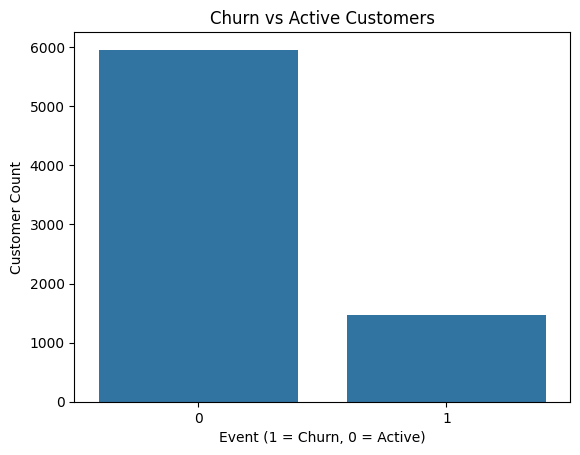

In [ ]:
sns.countplot(x="event", data=data)
plt.title("Churn vs Active Customers")
plt.xlabel("Event (1 = Churn, 0 = Active)")
plt.ylabel("Customer Count")
plt.show()

## Tenure Distribution

This helps us understand the customer lifecycle length.

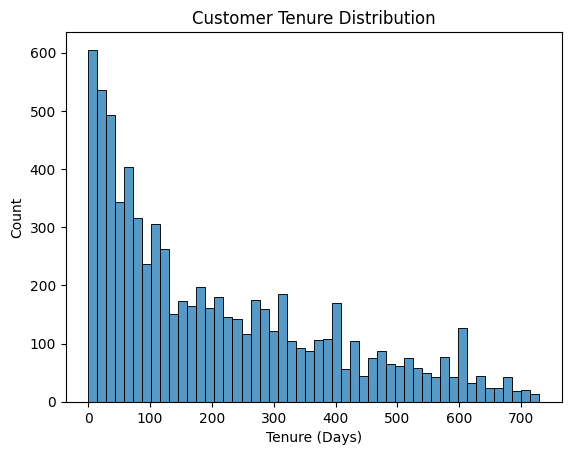

In [ ]:
sns.histplot(data["tenure_days"], bins=50)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Days)")
plt.show()

## Engagement Analysis

Analyze product usage behavior.

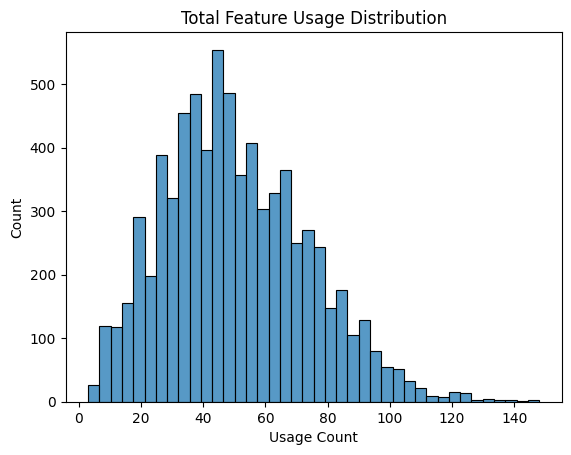

In [ ]:
sns.histplot(data["usage_count"], bins=40)
plt.title("Total Feature Usage Distribution")
plt.xlabel("Usage Count")
plt.show()

## Usage vs Churn

We analyze how engagement relates to churn.

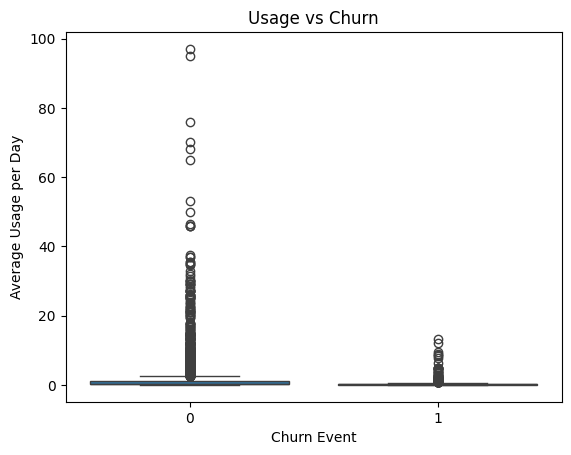

In [ ]:
sns.boxplot(x="event", y="avg_usage_per_day", data=data)

plt.title("Usage vs Churn")
plt.xlabel("Churn Event")
plt.ylabel("Average Usage per Day")
plt.show()

## Support Ticket Behavior

Support interactions may indicate customer frustration.

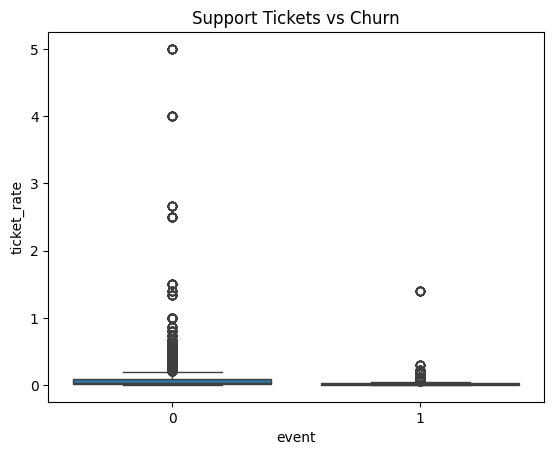

In [ ]:
sns.boxplot(x="event", y="ticket_rate", data=data)

plt.title("Support Tickets vs Churn")
plt.show()

## Financial Analysis

Analyze revenue behavior.

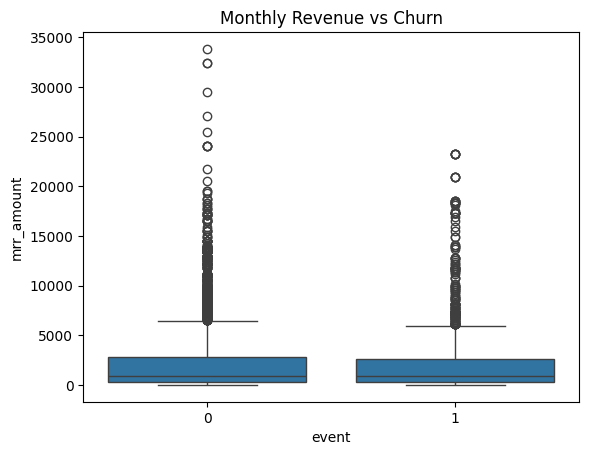

In [ ]:
sns.boxplot(x="event", y="mrr_amount", data=data)

plt.title("Monthly Revenue vs Churn")
plt.show()

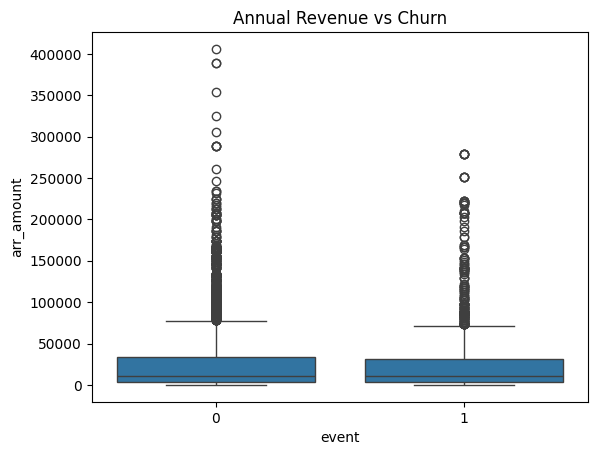

In [ ]:
sns.boxplot(x="event", y="arr_amount", data=data)

plt.title("Annual Revenue vs Churn")
plt.show()

## Feature Correlation

We examine relationships between numeric variables.

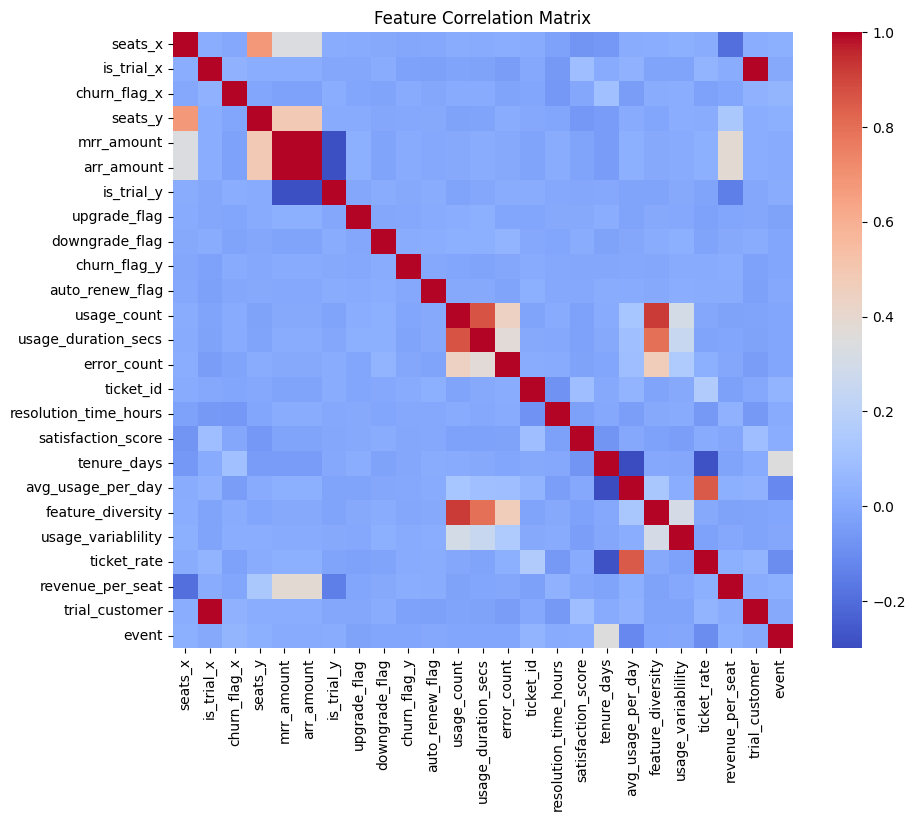

In [ ]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

## Kaplan Meier Survival Analysis

Now we analyze survival probability over time.

This is a core survival analysis technique.

Concept:
The Kaplan Meier estimator estimates - S(t) = P(T>t)

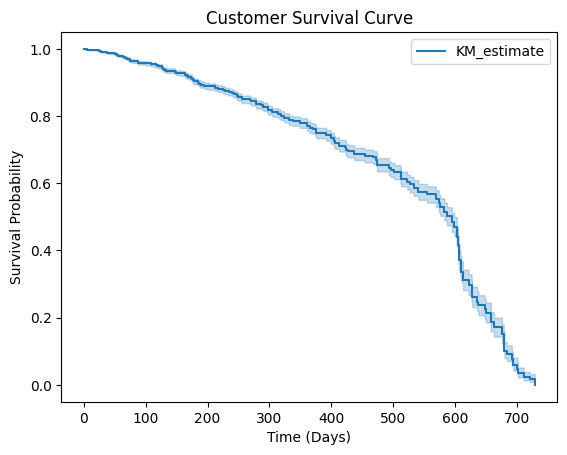

In [ ]:
kmf = KaplanMeierFitter()

kmf.fit(
    durations=data["tenure_days"],
    event_observed=data["event"]
)

kmf.plot_survival_function()

plt.title("Customer Survival Curve")
plt.xlabel("Time (Days)")
plt.ylabel("Survival Probability")
plt.show()

## Segment Survival Analysis

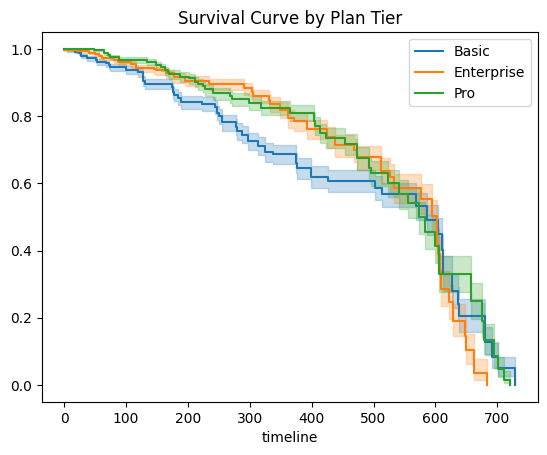

In [ ]:
for plan in data["plan_tier_x"].unique():

    subset = data[data["plan_tier_x"] == plan]

    kmf.fit(
        subset["tenure_days"],
        subset["event"],
        label=plan
    )

    kmf.plot_survival_function()

plt.title("Survival Curve by Plan Tier")
plt.show()

# Dataset Construction


## Duration

In [ ]:
data["duration"] = data["tenure_days"]

In [ ]:
assert (data["duration"]>=0).all(), "Negative durations found!"

In [ ]:
data["duration"].describe()

,duration
count,7429.000000
mean,207.723516
std,183.436241
min,0.000000
25%,52.000000
50%,151.000000
75%,321.000000
max,729.000000


## Event Variable


In [ ]:
data["event"] = data["churn_date"].notnull().astype(int)

In [ ]:
data["event"]

,event
0,1
1,1
2,1
3,1
4,1
...,...
7424,1
7425,1
7426,1
7427,1


## Feature Columns

In [ ]:
features = [
    "avg_usage_per_day",
    "feature_diversity",
    "usage_variablility",
    "ticket_rate",
    "mrr_amount",
    "revenue_per_seat",
    "trial_customer"
]

In [ ]:
survival_data = data[features + ["duration", "event"]]

In [ ]:
survival_data.isnull().sum()

,0
avg_usage_per_day,55
feature_diversity,55
usage_variablility,294
ticket_rate,88
mrr_amount,0
revenue_per_seat,0
trial_customer,0
duration,0
event,0


In [ ]:
survival_data.fillna(0, inplace=True)

/tmp/ipykernel_3539/3029289080.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  survival_data.fillna(0, inplace=True)


In [ ]:
survival_data = pd.get_dummies(survival_data, drop_first=True)

## Feature Scaling

In [ ]:
scaler = StandardScaler()

X = survival_data.drop(columns=["duration","event"])

X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

X_scaled = scaler.fit_transform(X)

survival_data_scaled = pd.DataFrame(X_scaled, columns=X.columns)

survival_data_scaled["duration"] = survival_data["duration"]
survival_data_scaled["event"] = survival_data["event"]

## Train-Test Split

In [ ]:
train_data, test_data = train_test_split(
    survival_data_scaled,
    test_size=0.2,
    random_state=42
)

In [ ]:
survival_data_scaled.to_csv("survival_dataset.csv", index=False)

# Model Development


## Cox Proportional Hazards Model

In [ ]:
cph = CoxPHFitter()

cph.fit(
    survival_data_scaled,
    duration_col="duration",
    event_col="event"
)

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 7429 total observations, 1472 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 7429
number of events observed = 5957
   partial log-likelihood = -46814.90
         time fit was run = 2026-04-16 05:02:49 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
avg_usage_per_day   0.33      1.39      0.03            0.27            0.38                1.31                1.47
feature_diversity  -0.03      0.97      0.01           -0.06           -0.01                0.94                0.99
usage_variablility  0.02      1.02      0.01           -0.01            0.04                0.99                1.05
ticket_rate         1.75      5.77      0.06            1.64            1.87                5.14                6.47
mrr_amount          0.05      1.05      0.01            0.02            0.08                1.02                1.08
revenue_per_seat   -0.01      0.99      0.02           -0.04            0.02                0.96                1.02
trial_customer     -0.02      0.98      0.01           -0.05            0.01                0.95                1.01

                    cmp to     z      p  -log2(p)
covariate                                        
avg_usage_per_day     0.00 11.48 <0.005     98.85
feature_diversity     0.00 -2.51   0.01      6.36
usage_variablility    0.00  1.27   0.20      2.29
ticket_rate           0.00 29.76 <0.005    644.02
mrr_amount            0.00  3.59 <0.005     11.56
revenue_per_seat      0.00 -0.92   0.36      1.49
trial_customer        0.00 -1.47   0.14      2.81
---
Concordance = 0.86
Partial AIC = 93643.81
log-likelihood ratio test = 2961.41 on 7 df
-log2(p) of ll-ratio test = inf

Case 1 — exp(coef) > 1
feature increases churn risk
Case 2 — exp(coef) < 1
feature reduces churn risk


In [ ]:
cph.concordance_index_

np.float64(0.8572423031911405)

0.5	random
0.6–0.7	moderate
0.7–0.8	good
0.8+	excellent

<Axes: xlabel='log(HR) (95% CI)'>

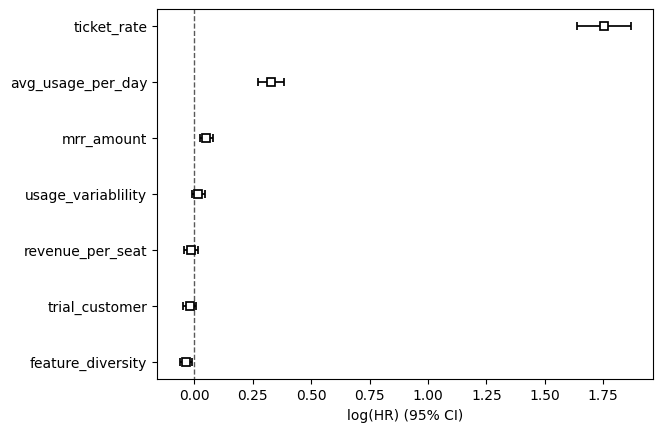

In [ ]:
cph.plot()

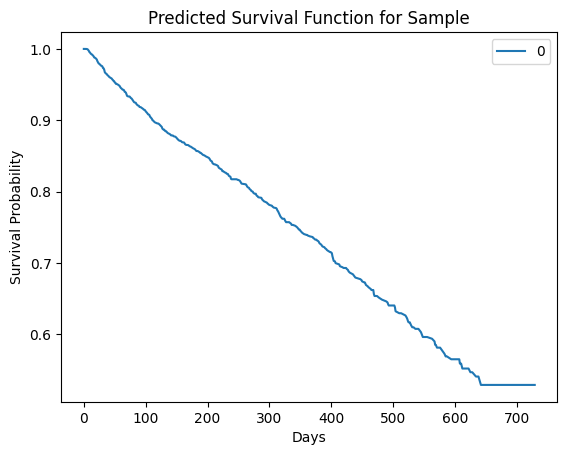

In [ ]:
# Define sample by taking a row from the test set (without duration/event columns)
sample = test_data.drop(columns=['duration', 'event']).iloc[[0]]

# Scale the sample using the previously fitted scaler
sample_scaled = scaler.transform(sample)
sample_df = pd.DataFrame(sample_scaled, columns=X.columns)

# Predict and plot
cph.predict_survival_function(sample_df).plot()
plt.title('Predicted Survival Function for Sample')
plt.xlabel('Days')
plt.ylabel('Survival Probability')
plt.show()

## Deep Surv Model

In [ ]:
X = survival_data_scaled.drop(columns=["duration","event"]).values.astype("float32")
y_duration = survival_data_scaled["duration"].values.astype("float32")
y_event = survival_data_scaled["event"].values.astype("float32")

# Neural network
net = nn.Sequential(
    nn.Linear(X.shape[1], 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

# Model
model = CoxPH(net, tt.optim.Adam)

# Train
model.fit(
    X,
    (y_duration, y_event),
    batch_size=256,
    epochs=50,
    verbose=True
)

0:	[0s / 0s],		train_loss: 4.6118
1:	[0s / 0s],		train_loss: 4.5598
2:	[0s / 0s],		train_loss: 4.4590
3:	[0s / 0s],		train_loss: 4.3755
4:	[0s / 0s],		train_loss: 4.2891
5:	[0s / 1s],		train_loss: 4.1904
6:	[0s / 1s],		train_loss: 4.0622
7:	[0s / 1s],		train_loss: 3.9289
8:	[0s / 1s],		train_loss: 3.8255
9:	[0s / 2s],		train_loss: 3.7056
10:	[0s / 2s],		train_loss: 3.6470
11:	[0s / 2s],		train_loss: 3.5796
12:	[0s / 2s],		train_loss: 3.5436
13:	[0s / 2s],		train_loss: 3.5029
14:	[0s / 2s],		train_loss: 3.4730
15:	[0s / 2s],		train_loss: 3.4399
16:	[0s / 3s],		train_loss: 3.4132
17:	[0s / 3s],		train_loss: 3.3827
18:	[0s / 3s],		train_loss: 3.3699
19:	[0s / 3s],		train_loss: 3.3509
20:	[0s / 3s],		train_loss: 3.3144
21:	[0s / 3s],		train_loss: 3.2938
22:	[0s / 3s],		train_loss: 3.2845
23:	[0s / 4s],		train_loss: 3.2651
24:	[0s / 4s],		train_loss: 3.2550
25:	[0s / 4s],		train_loss: 3.2363
26:	[0s / 4s],		train_loss: 3.2288
27:	[0s / 4s],		train_loss: 3.2089
28:	[0s / 4s],		train_loss: 3.

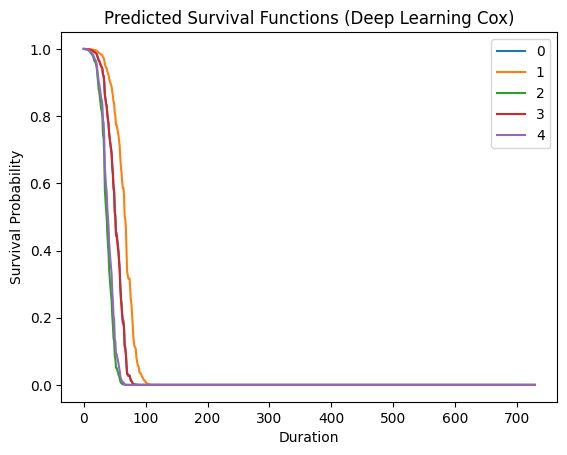

In [ ]:
model.compute_baseline_hazards(X, (y_duration, y_event))
surv = model.predict_surv_df(X[:5])
surv.plot()
import matplotlib.pyplot as plt
plt.title("Predicted Survival Functions (Deep Learning Cox)")
plt.xlabel("Duration")
plt.ylabel("Survival Probability")
plt.show()

# Model Evaluation

In [ ]:
cox_pred = cph.predict_partial_hazard(survival_data)

c_index_cox = concordance_index(
    survival_data["duration"],
    -cox_pred,  # negative because higher hazard = higher risk
    survival_data["event"]
)

print("Cox C-index:", c_index_cox)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


Cox C-index: 0.5318323748715006


In [ ]:
deep_pred = model.predict(X).flatten()

c_index_deep = concordance_index(
    survival_data["duration"],
    -deep_pred,
    survival_data["event"]
)

print("DeepSurv C-index:", c_index_deep)

DeepSurv C-index: 0.9404215245399229


In [ ]:
results = {
    "Model": ["Cox","DeepSurv"],
    "C-index": [c_index_cox,c_index_deep]
}
results_df = pd.DataFrame(results)
print(results_df)

      Model   C-index
0       Cox  0.531832
1  DeepSurv  0.940422


<Axes: xlabel='Model'>

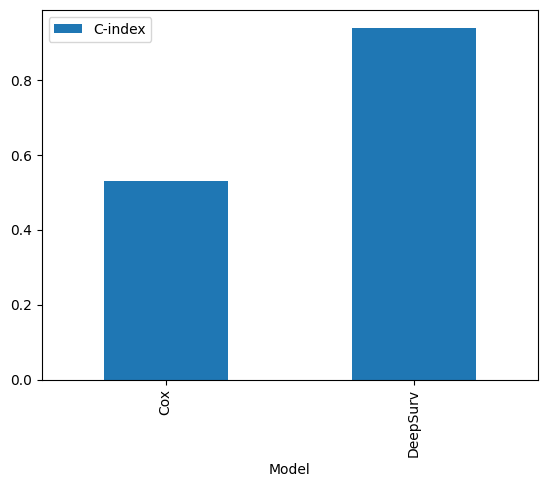

In [ ]:
results_df.set_index("Model").plot(kind="bar")